# Social Media Self-Diagnosis Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
df_survey = pd.read_csv("survey_data.csv")
df_trends = pd.read_csv("trends_data.csv")
df_behavioral = pd.read_csv("behavioral_data.csv")

print(f"Survey shape: {df_survey.shape}")
print(f"Trends shape: {df_trends.shape}")
print(f"Behavioral shape: {df_behavioral.shape}")

Survey shape: (355, 17)
Trends shape: (61, 4)
Behavioral shape: (5000, 19)


In [4]:
print("=== Datasets Overview ===")
print(f"1. Survey (Self-Diagnosis)          → {df_survey.shape[0]} مشارك")
print(f"2. Google Trends (2021-2026)       → {df_trends.shape[0]} شهر")
print(f"3. Behavioral Impact (Kaggle)      → {df_behavioral.shape[0]} records")

=== Datasets Overview ===
1. Survey (Self-Diagnosis)          → 355 مشارك
2. Google Trends (2021-2026)       → 61 شهر
3. Behavioral Impact (Kaggle)      → 5000 records


## Key Insights from Each Dataset

In [9]:
# Survey - Most common self-diagnosed conditions
conditions = (df_survey['Commonly Self-Diagnosed Conditions Observed']
              .str.split(', ')
              .explode()
              .value_counts()
              .head(8))

print("Most common self-diagnosed conditions:")
print(conditions, "\n")

# Trends - Peak month (fixed)
peak_idx = df_trends['Anxiety_Search_Index'].idxmax()
peak_month = df_trends.loc[peak_idx, 'Date'] if 'Date' in df_trends.columns else df_trends.index[peak_idx]
print(f"Peak in mental health search interest: {peak_month} (index = 100)\n")

# Behavioral - Mental state distribution
mental_dist = df_behavioral['mental_state'].value_counts(normalize=True) * 100
print("Mental state distribution (%):")
print(mental_dist.round(1))

Most common self-diagnosed conditions:
Commonly Self-Diagnosed Conditions Observed
Depression          187
ADHD                128
Anxiety             122
Other               111
Autism               87
Digestive Issues     84
Bipolar Disorder     77
Name: count, dtype: int64 

Peak in mental health search interest: 59 (index = 100)

Mental state distribution (%):
mental_state
Stressed    92.0
Healthy      6.8
At_Risk      1.2
Name: proportion, dtype: float64


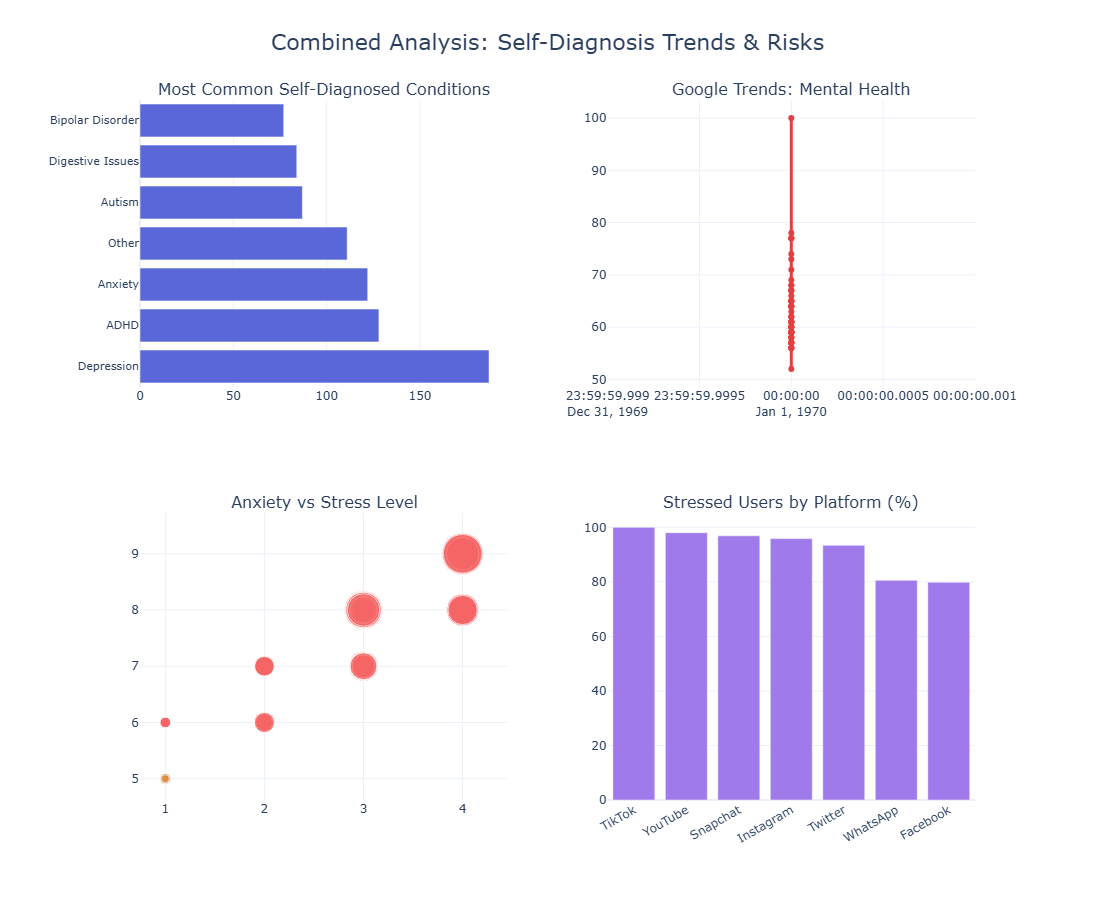

In [25]:
# Combined Dashboard 
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Most Common Self-Diagnosed Conditions",
        "Google Trends: Mental Health",
        "Anxiety vs Stress Level",
        "Stressed Users by Platform (%)"
    ),
    specs=[[{"type": "bar"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "bar"}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.18
)

#  Plot 1 
fig.add_trace(
    go.Bar(
        x=conditions.values,
        y=conditions.index,
        orientation='h',
        marker=dict(color="#5A67D8")
    ),
    row=1, col=1
)

# Plot 2 

if 'Date' in df_trends.columns:
    date_col = 'Date'
elif 'date' in df_trends.columns:
    date_col = 'date'
else:
    df_trends = df_trends.reset_index(drop=True)  # يمنع تكرار الأعمدة
    date_col = df_trends.columns[0]
fig.add_trace(
    go.Scatter(
        x=pd.to_datetime(df_trends[date_col]),
        y=df_trends['Anxiety_Search_Index'],
        mode='lines+markers',
        line=dict(width=3, color="#E53E3E"),
        marker=dict(size=6)
    ),
    row=1, col=2
)

# Plot 3
fig.add_trace(
    go.Scatter(
        x=df_behavioral['anxiety_level'],
        y=df_behavioral['stress_level'],
        mode='markers',
        marker=dict(
            size=df_behavioral['social_media_time_min'] / 8,
            color=df_behavioral['mental_state'].map({
                'Healthy': '#38B2AC',
                'Stressed': '#F56565',
                'At_Risk': '#ED8936'
            }),
            opacity=0.75,
            line=dict(width=1, color="white")
        )
    ),
    row=2, col=1
)

#  Plot 4
platform_stress = df_behavioral.groupby('platform')['mental_state'] \
    .apply(lambda x: (x == 'Stressed').mean() * 100) \
    .sort_values(ascending=False)

fig.add_trace(
    go.Bar(
        x=platform_stress.index,
        y=platform_stress.values,
        marker=dict(color="#9F7AEA")
    ),
    row=2, col=2
)


fig.update_layout(
    height=900,
    width=1300,

    title=dict(
        text="Combined Analysis: Self-Diagnosis Trends & Risks",
        x=0.5,
        font=dict(size=22)
    ),

    
    margin=dict(l=140, r=120, t=100, b=100),

    font=dict(size=12),
    template="plotly_white",
    showlegend=False
)


fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)


fig.update_yaxes(tickfont=dict(size=11), row=1, col=1)


fig.update_xaxes(tickangle=-30, row=2, col=2)

fig.show()

##  Conclusion & Recommendations

**Overall Story:**
- Users frequently self-diagnose mental health conditions (ADHD, Anxiety, Depression, and Bipolar are the most common).
- Google search interest in mental health has been rising steadily, with a major peak in February 2026.
- Higher social media usage is strongly associated with increased anxiety, stress, and a higher percentage of "Stressed" and "At_Risk" mental states. TikTok and Instagram show the highest risk levels.

**Key Recommendations:**
- Social media platforms should add warnings or content filters for self-diagnosis videos.
- Launch public awareness campaigns about the risks of self-diagnosis.
- Verified medical creators should be prioritized and clearly labeled.

**Future Work:**
- Expand analysis to Instagram and Reddit.
- Build a real-time trend monitoring dashboard.
- Develop a predictive model for user risk level based on social media time and interactions.